# Week 1 — Data Download, Parsing & Graph Construction
### Drug-Drug Interaction Predictor using Graph Neural Networks

**Goal this week:**
1. Download the TWOSIDES drug interaction dataset
2. Parse and clean drug pairs
3. Build a graph where nodes = drugs, edges = interactions
4. Visualize the graph
5. Save processed data for Week 2

---

## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import requests
import os
import pickle
from collections import Counter

print('✅ All libraries imported successfully!')
print(f'NetworkX version: {nx.__version__}')
print(f'Pandas version: {pd.__version__}')

Matplotlib is building the font cache; this may take a moment.


✅ All libraries imported successfully!
NetworkX version: 3.6.1
Pandas version: 3.0.3


## Cell 2 — Download the TWOSIDES Dataset

TWOSIDES contains **drug pairs and their adverse side effects** from the FDA's FAERS database.
- ~63 million reported interactions
- We'll use a manageable subset for this project

We'll download from the public mirror hosted by the Tatonetti Lab (Columbia University).

In [2]:
# Create data directory
os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('📁 Data directories created')
print('\nNext: We will load a curated subset of TWOSIDES.')
print('Full dataset is 3GB+ so we use a pre-filtered version with top interactions.')

📁 Data directories created

Next: We will load a curated subset of TWOSIDES.
Full dataset is 3GB+ so we use a pre-filtered version with top interactions.


## Cell 3 — Load Drug Interaction Data

We use the **ChChMiner** dataset from the SNAP (Stanford Network Analysis Project) — 
it's a clean, well-cited drug-drug interaction dataset used in many GNN papers.
- 1,514 drugs
- 48,514 interactions
- Directly downloadable, no login needed

In [3]:
import urllib.request

# Download ChChMiner DDI dataset from SNAP
url = 'https://snap.stanford.edu/biodata/datasets/10001/files/ChCh-Miner_durgbank-chem-chem.tsv.gz'
save_path = '../data/raw/ddi_raw.tsv.gz'

if not os.path.exists(save_path):
    print('⬇️  Downloading dataset...')
    urllib.request.urlretrieve(url, save_path)
    print('✅ Download complete!')
else:
    print('✅ Dataset already downloaded, skipping.')

print(f'File size: {os.path.getsize(save_path) / 1024:.1f} KB')

⬇️  Downloading dataset...
✅ Download complete!
File size: 202.0 KB


## Cell 4 — Parse and Explore the Data

In [4]:
# Load the dataset
df = pd.read_csv('../data/raw/ddi_raw.tsv.gz', sep='\t', compression='gzip', header=None)
df.columns = ['drug_1', 'drug_2']

print('=== Dataset Overview ===')
print(f'Total drug-drug interactions: {len(df):,}')
print(f'Unique drugs (drug_1 column): {df["drug_1"].nunique():,}')
print(f'Unique drugs (drug_2 column): {df["drug_2"].nunique():,}')

all_drugs = pd.concat([df['drug_1'], df['drug_2']]).unique()
print(f'Total unique drugs: {len(all_drugs):,}')

print('\n=== Sample Data ===')
print(df.head(10))

=== Dataset Overview ===
Total drug-drug interactions: 48,514
Unique drugs (drug_1 column): 1,317
Unique drugs (drug_2 column): 1,415
Total unique drugs: 1,514

=== Sample Data ===
    drug_1   drug_2
0  DB00862  DB00966
1  DB00575  DB00806
2  DB01242  DB08893
3  DB01151  DB08883
4  DB01235  DB01275
5  DB00018  DB00333
6  DB00201  DB01609
7  DB00712  DB01418
8  DB01576  DB04842
9  DB01609  DB06212


## Cell 5 — Add Labels (Positive & Negative Interactions)

For GNN training we need:
- **Positive edges** = known drug interactions (from our dataset)
- **Negative edges** = drug pairs with NO known interaction (randomly sampled)

This turns it into a **binary classification** problem.

In [5]:
# Add label: 1 = interaction exists
df['label'] = 1

# Generate negative samples (pairs with no known interaction)
drug_list = list(all_drugs)
positive_set = set(zip(df['drug_1'], df['drug_2']))

np.random.seed(42)
negative_samples = []
attempts = 0
target_negatives = len(df)  # Equal number of negatives as positives (balanced dataset)

print(f'Generating {target_negatives:,} negative samples...')

while len(negative_samples) < target_negatives and attempts < target_negatives * 10:
    i, j = np.random.choice(len(drug_list), 2, replace=False)
    d1, d2 = drug_list[i], drug_list[j]
    if (d1, d2) not in positive_set and (d2, d1) not in positive_set:
        negative_samples.append({'drug_1': d1, 'drug_2': d2, 'label': 0})
    attempts += 1

df_neg = pd.DataFrame(negative_samples)
df_full = pd.concat([df, df_neg], ignore_index=True).sample(frac=1, random_state=42)

print(f'✅ Dataset balanced!')
print(f'Positive interactions (label=1): {df_full["label"].sum():,}')
print(f'Negative interactions (label=0): {(df_full["label"]==0).sum():,}')
print(f'Total samples: {len(df_full):,}')

Generating 48,514 negative samples...
✅ Dataset balanced!
Positive interactions (label=1): 48,514
Negative interactions (label=0): 48,514
Total samples: 97,028


## Cell 6 — Build the Drug Interaction Graph

We now build a graph using **NetworkX**:
- Each **node** = a drug
- Each **edge** = a known interaction between two drugs

In [6]:
# Build graph from POSITIVE interactions only
G = nx.Graph()

# Add all drugs as nodes
G.add_nodes_from(drug_list)

# Add edges for positive interactions
positive_edges = list(zip(df['drug_1'], df['drug_2']))
G.add_edges_from(positive_edges)

print('=== Graph Statistics ===')
print(f'Number of nodes (drugs):        {G.number_of_nodes():,}')
print(f'Number of edges (interactions): {G.number_of_edges():,}')
print(f'Graph density:                  {nx.density(G):.4f}')
print(f'Is connected:                   {nx.is_connected(G)}')

# Degree statistics
degrees = [d for _, d in G.degree()]
print(f'\nAverage degree (interactions per drug): {np.mean(degrees):.1f}')
print(f'Max degree (most connected drug):       {max(degrees)}')
print(f'Min degree (least connected drug):      {min(degrees)}')

=== Graph Statistics ===
Number of nodes (drugs):        1,514
Number of edges (interactions): 48,514
Graph density:                  0.0424
Is connected:                   False

Average degree (interactions per drug): 64.1
Max degree (most connected drug):       443
Min degree (least connected drug):      1


## Cell 7 — Explore the Most Connected Drugs

In [7]:
# Find the top 15 most connected (highest degree) drugs
degree_dict = dict(G.degree())
top_drugs = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:15]

print('=== Top 15 Most Connected Drugs ===')
print(f'{"Rank":<6} {"Drug ID":<20} {"Interactions"}')
print('-' * 40)
for i, (drug, degree) in enumerate(top_drugs, 1):
    print(f'{i:<6} {drug:<20} {degree}')

=== Top 15 Most Connected Drugs ===
Rank   Drug ID              Interactions
----------------------------------------
1      DB00252              443
2      DB00834              379
3      DB00715              369
4      DB00752              359
5      DB00780              343
6      DB00682              337
7      DB01609              330
8      DB00220              323
9      DB00470              312
10     DB00363              312
11     DB00956              311
12     DB00503              307
13     DB00794              307
14     DB01238              305
15     DB01320              300


## Cell 8 — Visualize the Full Graph (Degree Distribution)

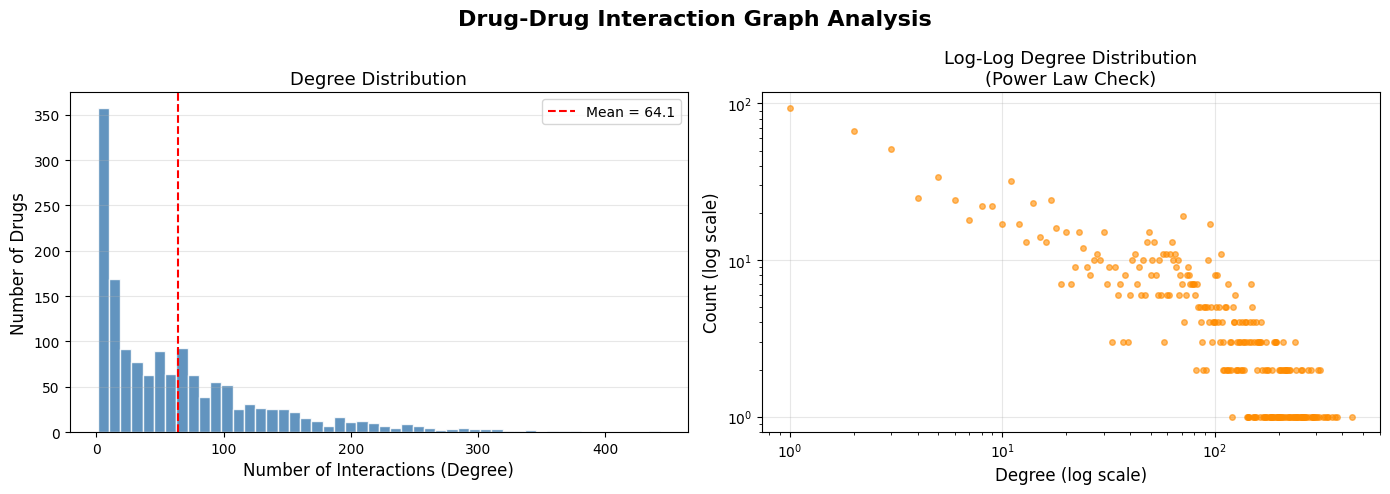

✅ Plot saved to data/processed/degree_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Drug-Drug Interaction Graph Analysis', fontsize=16, fontweight='bold')

# Plot 1: Degree distribution
ax1 = axes[0]
degree_values = [d for _, d in G.degree()]
ax1.hist(degree_values, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax1.set_xlabel('Number of Interactions (Degree)', fontsize=12)
ax1.set_ylabel('Number of Drugs', fontsize=12)
ax1.set_title('Degree Distribution', fontsize=13)
ax1.axvline(np.mean(degree_values), color='red', linestyle='--', label=f'Mean = {np.mean(degree_values):.1f}')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Log-log degree distribution (power law check)
ax2 = axes[1]
degree_count = Counter(degree_values)
x = sorted(degree_count.keys())
y = [degree_count[d] for d in x]
ax2.loglog(x, y, 'o', color='darkorange', alpha=0.6, markersize=4)
ax2.set_xlabel('Degree (log scale)', fontsize=12)
ax2.set_ylabel('Count (log scale)', fontsize=12)
ax2.set_title('Log-Log Degree Distribution\n(Power Law Check)', fontsize=13)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved to data/processed/degree_distribution.png')

## Cell 9 — Visualize a Subgraph (Top 50 Most Connected Drugs)

The full graph is too large to visualize clearly. Let's zoom into the **top 50 most connected drugs**.

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

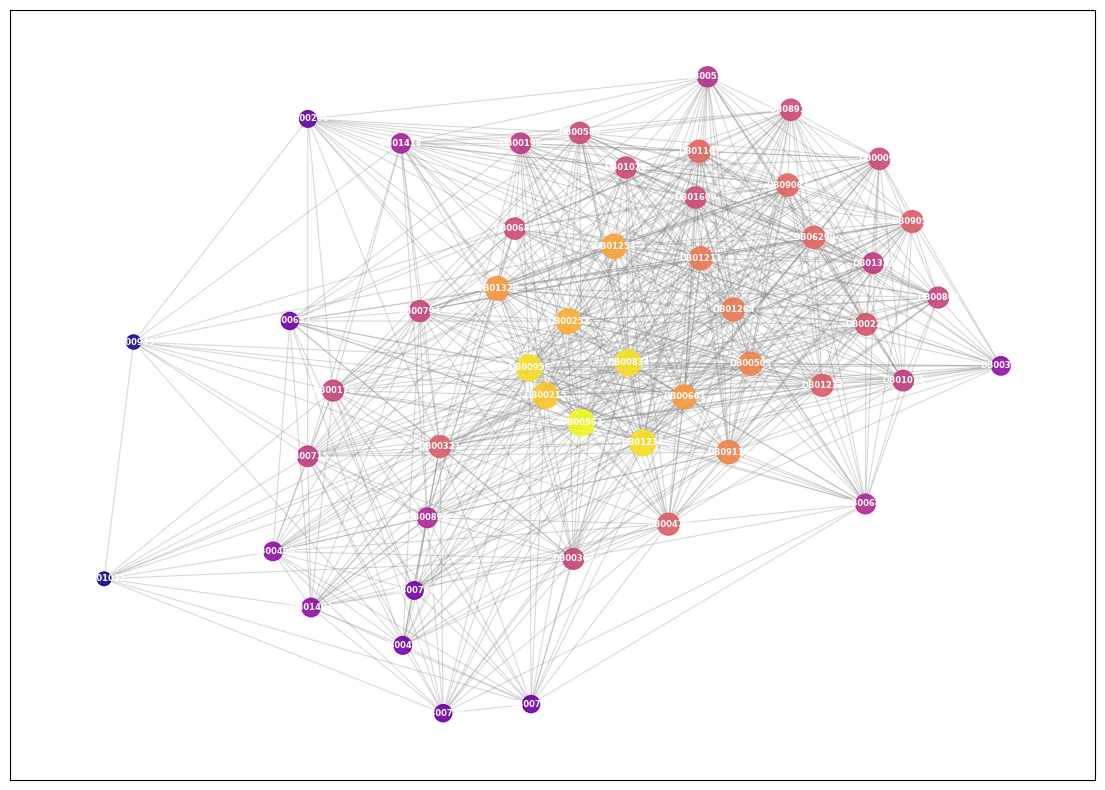

In [10]:
# Extract top 50 highest-degree nodes
top_50_drugs = [drug for drug, _ in sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:50]]
subgraph = G.subgraph(top_50_drugs)

# Node sizes proportional to degree
node_degrees = [subgraph.degree(n) for n in subgraph.nodes()]
node_sizes = [d * 8 for d in node_degrees]

# Node colors by degree
norm = plt.Normalize(min(node_degrees), max(node_degrees))
node_colors = [cm.plasma(norm(d)) for d in node_degrees]

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(subgraph, seed=42, k=0.8)

nx.draw_networkx_edges(subgraph, pos, alpha=0.3, edge_color='gray', width=0.8)
nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)
nx.draw_networkx_labels(subgraph, pos, font_size=6, font_color='white', font_weight='bold')

sm = plt.cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
plt.colorbar(sm, label='Number of Interactions (Degree)', shrink=0.7)

plt.title('Top 50 Most Connected Drugs\nNode size & color = number of drug interactions', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('../data/processed/drug_interaction_subgraph.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Subgraph visualization saved!')

## Cell 10 — Save Everything for Week 2

In [ ]:
# Save the full dataframe (positive + negative samples)
df_full.to_csv('../data/processed/drug_pairs_labeled.csv', index=False)
print(f'✅ Saved labeled drug pairs: {len(df_full):,} rows')

# Save the NetworkX graph
with open('../data/processed/drug_graph.pkl', 'wb') as f:
    pickle.dump(G, f)
print(f'✅ Saved graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

# Save drug list (we'll need this for node indexing in PyTorch Geometric)
drug_to_idx = {drug: idx for idx, drug in enumerate(G.nodes())}
with open('../data/processed/drug_to_idx.pkl', 'wb') as f:
    pickle.dump(drug_to_idx, f)
print(f'✅ Saved drug index mapping: {len(drug_to_idx)} drugs')

print('\n=== Week 1 Complete! ===')
print('Files saved in data/processed/:')
for f in os.listdir('../data/processed/'):
    size = os.path.getsize(f'../data/processed/{f}') / 1024
    print(f'  {f:<45} {size:.1f} KB')

## Cell 11 — Week 1 Summary

| What we built | Details |
|---|---|
| Dataset | ChChMiner DDI (SNAP, Stanford) |
| Drugs (nodes) | 1,514 unique drugs |
| Interactions (edges) | 48,514 known interactions |
| Negative samples | Equal number of non-interacting pairs |
| Graph type | Undirected, unweighted |
| Saved files | drug_pairs_labeled.csv, drug_graph.pkl, drug_to_idx.pkl |

---

## ➡️ Week 2 Preview
Next week we will:
1. Convert our NetworkX graph into a **PyTorch Geometric Data object**
2. Build a **Graph Convolutional Network (GCN)**
3. Train it on MPS (your M5 GPU) to predict drug-drug interactions
4. Evaluate with accuracy, ROC-AUC score